# Data Loading & Initial Inspection

In [2]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the Dataset
df=pd.read_csv("Datasets\CreditCard.csv")

In [4]:
#Check the Shape, column of the dataset
print(f"Shape : {df.shape}\n")
print("columns : \n")
for i in df.columns:
    print(i)


Shape : (9709, 20)

columns : 

ID
Gender
Own_car
Own_property
Work_phone
Phone
Email
Unemployed
Num_children
Num_family
Account_length
Total_income
Age
Years_employed
Income_type
Education_type
Family_status
Housing_type
Occupation_type
Target


In [5]:
# datatypes of the dataset
df.dtypes

ID                   int64
Gender               int64
Own_car              int64
Own_property         int64
Work_phone           int64
Phone                int64
Email                int64
Unemployed           int64
Num_children         int64
Num_family           int64
Account_length       int64
Total_income       float64
Age                float64
Years_employed     float64
Income_type         object
Education_type      object
Family_status       object
Housing_type        object
Occupation_type     object
Target               int64
dtype: object

In [6]:
#Preview First Few Rows
df.head()

,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type,Target
0,5008804,1,1,1,1,0,0,0,0,2,15,427500.0,32.868574,12.435574,Working,Higher education,Civil marriage,Rented apartment,Other,1
1,5008806,1,1,1,0,0,0,0,0,2,29,112500.0,58.793815,3.104787,Working,Secondary / secondary special,Married,House / apartment,Security staff,0
2,5008808,0,0,1,0,1,1,0,0,1,4,270000.0,52.321403,8.353354,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,0
3,5008812,0,0,1,0,0,0,1,0,1,20,283500.0,61.504343,0.000000,Pensioner,Higher education,Separated,House / apartment,Other,0
4,5008815,1,1,1,1,1,1,0,0,2,5,270000.0,46.193967,2.105450,Working,Higher education,Married,House / apartment,Accountants,0


In [7]:
df.isnull().sum()

ID                 0
Gender             0
Own_car            0
Own_property       0
Work_phone         0
Phone              0
Email              0
Unemployed         0
Num_children       0
Num_family         0
Account_length     0
Total_income       0
Age                0
Years_employed     0
Income_type        0
Education_type     0
Family_status      0
Housing_type       0
Occupation_type    0
Target             0
dtype: int64

In [8]:
#Detect Basic Anomalies

df.describe()

,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,Account_length,Total_income,Age,Years_employed,Target
count,9.709000e+03,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9.709000e+03,9709.000000,9709.000000,9709.000000
mean,5.076105e+06,0.348749,0.367700,0.671542,0.217427,0.287671,0.087548,0.174683,0.422804,2.182614,27.270059,1.812282e+05,43.784093,5.664730,0.132145
std,4.080270e+04,0.476599,0.482204,0.469677,0.412517,0.452700,0.282650,0.379716,0.767019,0.932918,16.648057,9.927731e+04,11.625768,6.342241,0.338666
min,5.008804e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.700000e+04,20.504186,0.000000,0.000000
25%,5.036955e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,13.000000,1.125000e+05,34.059563,0.928150,0.000000
50%,5.069449e+06,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,26.000000,1.575000e+05,42.741466,3.761884,0.000000
75%,5.112986e+06,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,3.000000,41.000000,2.250000e+05,53.567151,8.200031,0.000000
max,5.150479e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.000000,20.000000,60.000000,1.575000e+06,68.863837,43.020733,1.000000


In [9]:
# Checking categorical column values:
for col in df.select_dtypes(include="object").columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())



Unique values in Income_type:
['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']

Unique values in Education_type:
['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']

Unique values in Family_status:
['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']

Unique values in Housing_type:
['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']

Unique values in Occupation_type:
['Other' 'Security staff' 'Sales staff' 'Accountants' 'Laborers'
 'Managers' 'Drivers' 'Core staff' 'High skill tech staff'
 'Cleaning staff' 'Private service staff' 'Cooking staff'
 'Low-skill Laborers' 'Medicine staff' 'Secretaries'
 'Waiters/barmen staff' 'HR staff' 'Realty agents' 'IT staff']


# DATA CLEANSING WITH PANDAS

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)


C:\Users\abdul\AppData\Local\Temp\ipykernel_22544\4170691528.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [11]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\abdul\AppData\Local\Temp\ipykernel_22544\3086599729.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [12]:
df.head()

,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type,Target
0,5008804,1,1,1,1,0,0,0,0,2,15,427500.0,32.868574,12.435574,Working,Higher education,Civil marriage,Rented apartment,Other,1
1,5008806,1,1,1,0,0,0,0,0,2,29,112500.0,58.793815,3.104787,Working,Secondary / secondary special,Married,House / apartment,Security staff,0
2,5008808,0,0,1,0,1,1,0,0,1,4,270000.0,52.321403,8.353354,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,0
3,5008812,0,0,1,0,0,0,1,0,1,20,283500.0,61.504343,0.000000,Pensioner,Higher education,Separated,House / apartment,Other,0
4,5008815,1,1,1,1,1,1,0,0,2,5,270000.0,46.193967,2.105450,Working,Higher education,Married,House / apartment,Accountants,0


In [13]:
df.dtypes

ID                   int64
Gender               int64
Own_car              int64
Own_property         int64
Work_phone           int64
Phone                int64
Email                int64
Unemployed           int64
Num_children         int64
Num_family           int64
Account_length       int64
Total_income       float64
Age                float64
Years_employed     float64
Income_type         object
Education_type      object
Family_status       object
Housing_type        object
Occupation_type     object
Target               int64
dtype: object

In [14]:
#Convert categorical variables into category type
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')


In [15]:
df.dtypes

ID                    int64
Gender                int64
Own_car               int64
Own_property          int64
Work_phone            int64
Phone                 int64
Email                 int64
Unemployed            int64
Num_children          int64
Num_family            int64
Account_length        int64
Total_income        float64
Age                 float64
Years_employed      float64
Income_type        category
Education_type     category
Family_status      category
Housing_type       category
Occupation_type    category
Target                int64
dtype: object

In [16]:
#Remove Duplicates
if 'ID' in df.columns:
    df.drop_duplicates(subset='ID', inplace=True)
else:
    df.drop_duplicates(inplace=True)  # fallback


In [17]:
df.duplicated().sum()


np.int64(0)

In [18]:
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].replace({
        1: 'Male',
        0: 'Female'
    })


In [19]:
df.head()

,ID,Gender,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,Account_length,Total_income,Age,Years_employed,Income_type,Education_type,Family_status,Housing_type,Occupation_type,Target
0,5008804,Male,1,1,1,0,0,0,0,2,15,427500.0,32.868574,12.435574,Working,Higher education,Civil marriage,Rented apartment,Other,1
1,5008806,Male,1,1,0,0,0,0,0,2,29,112500.0,58.793815,3.104787,Working,Secondary / secondary special,Married,House / apartment,Security staff,0
2,5008808,Female,0,1,0,1,1,0,0,1,4,270000.0,52.321403,8.353354,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,0
3,5008812,Female,0,1,0,0,0,1,0,1,20,283500.0,61.504343,0.000000,Pensioner,Higher education,Separated,House / apartment,Other,0
4,5008815,Male,1,1,1,1,1,0,0,2,5,270000.0,46.193967,2.105450,Working,Higher education,Married,House / apartment,Accountants,0


In [20]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [21]:
#Outlier Detection & Treatment

# num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# for col in num_cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     # Cap values outside the bounds
#     df[col] = np.where(df[col] < lower_bound, lower_bound,
#                        np.where(df[col] > upper_bound, upper_bound, df[col]))


In [22]:
df.shape

(9709, 20)

In [23]:
df.columns

Index(['ID', 'Gender', 'Own_car', 'Own_property', 'Work_phone', 'Phone',
       'Email', 'Unemployed', 'Num_children', 'Num_family', 'Account_length',
       'Total_income', 'Age', 'Years_employed', 'Income_type',
       'Education_type', 'Family_status', 'Housing_type', 'Occupation_type',
       'Target'],
      dtype='object')

In [24]:
df.dtypes

ID                    int64
Gender               object
Own_car               int64
Own_property          int64
Work_phone            int64
Phone                 int64
Email                 int64
Unemployed            int64
Num_children          int64
Num_family            int64
Account_length        int64
Total_income        float64
Age                 float64
Years_employed      float64
Income_type        category
Education_type     category
Family_status      category
Housing_type       category
Occupation_type    category
Target                int64
dtype: object

# UNIVARIATE ANALYSIS

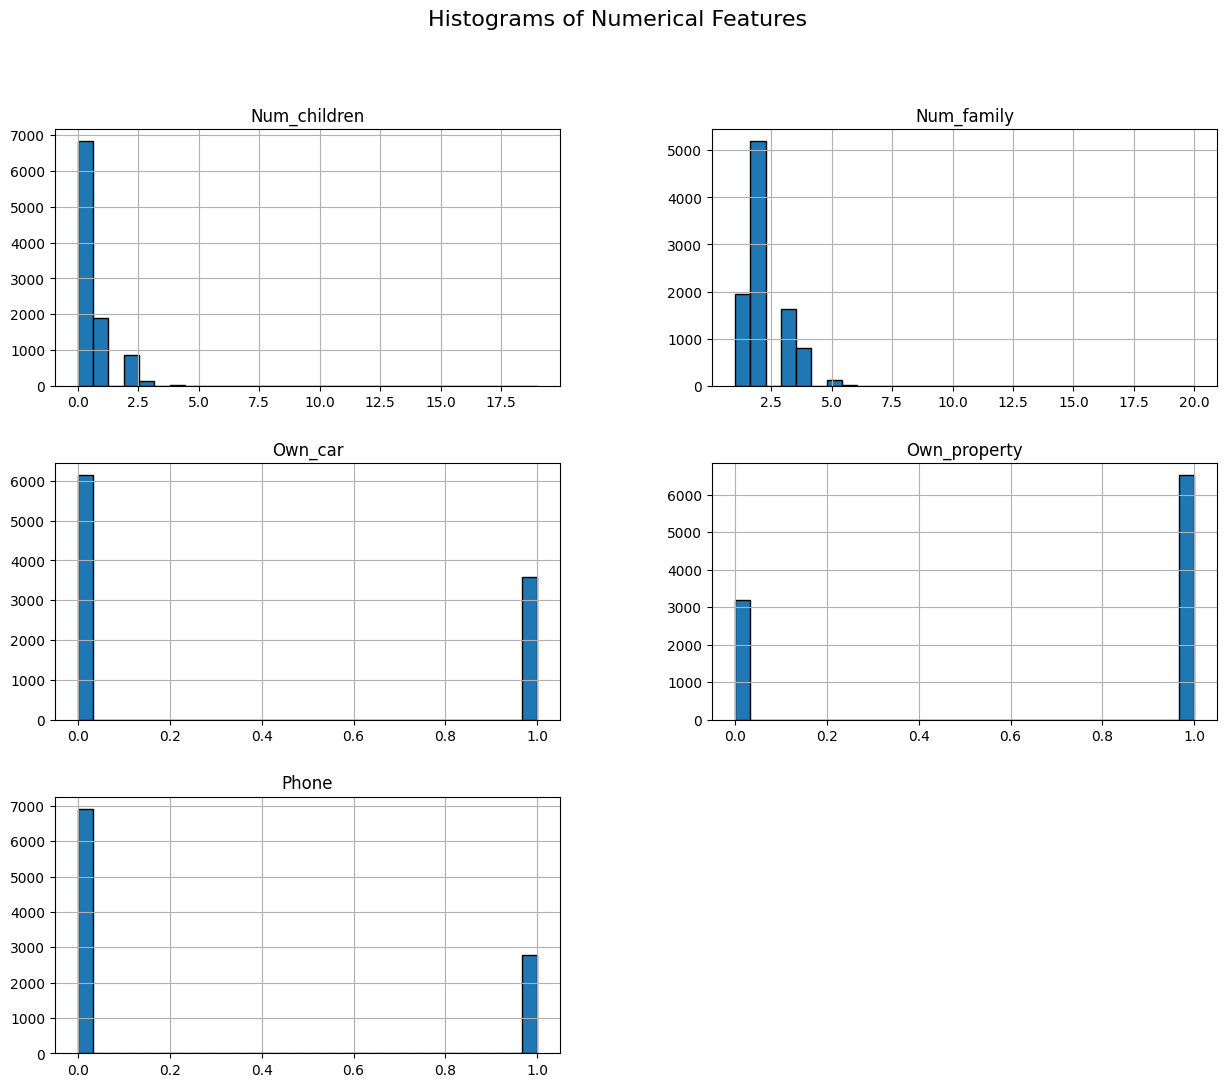

In [25]:
exclude_cols = ['ID', 'Work_phone', 'Email','Unemployed','Account_length','Total_income','Age','Years_employed','Target']

num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols2 = num_cols.difference(exclude_cols)

df[num_cols2].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.show()



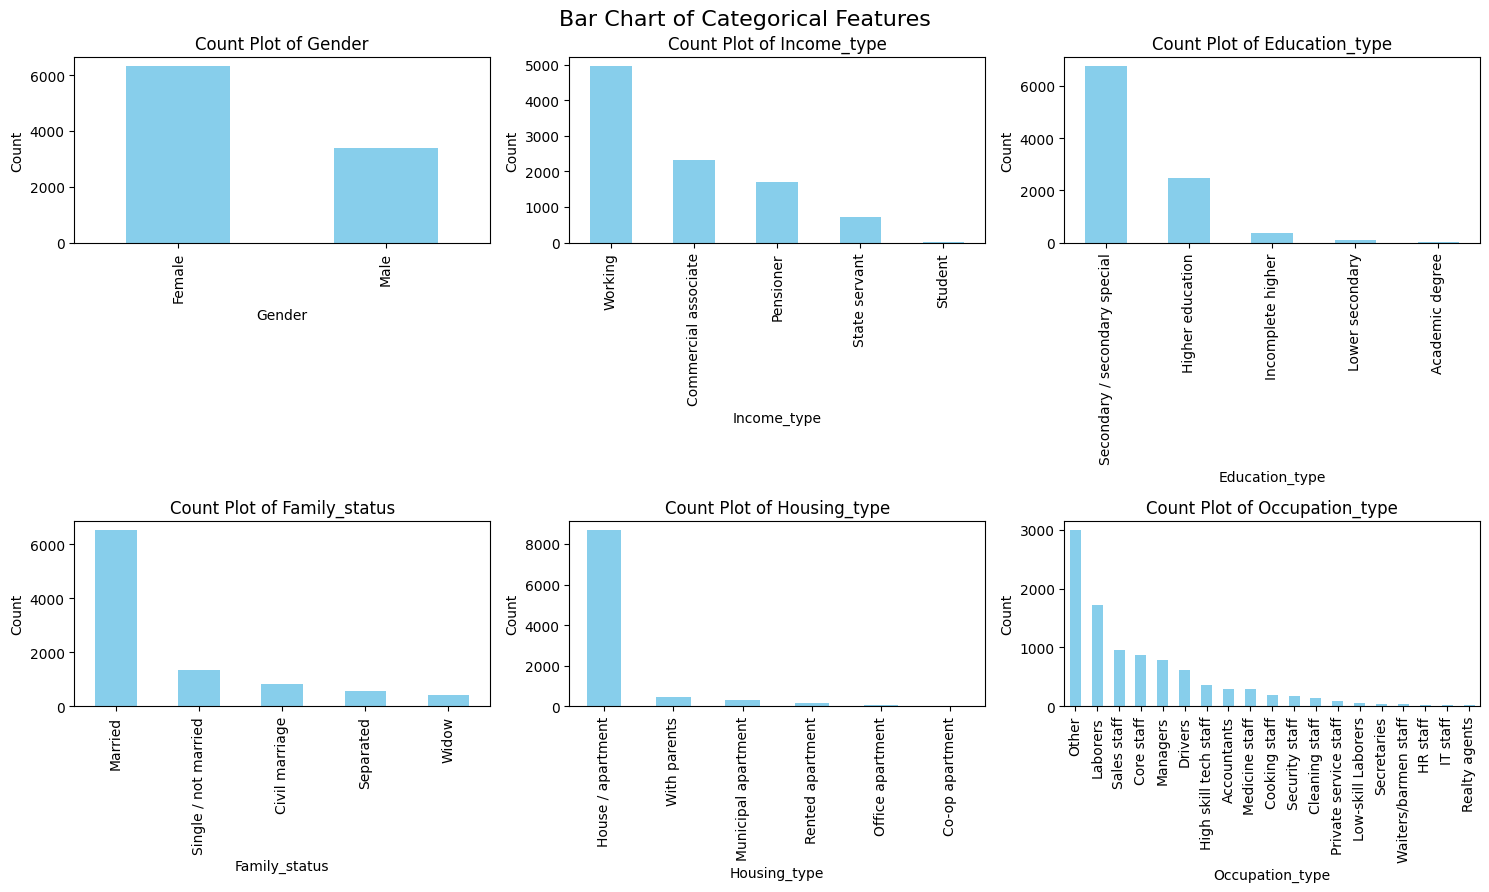

In [26]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns


plt.figure(figsize=(15, 12))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols)//3 + 1, 3, i)
    df[col].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
plt.suptitle("Bar Chart of Categorical Features", fontsize=16)
plt.tight_layout()
plt.show()


# BIVARIATE ANALYSIS

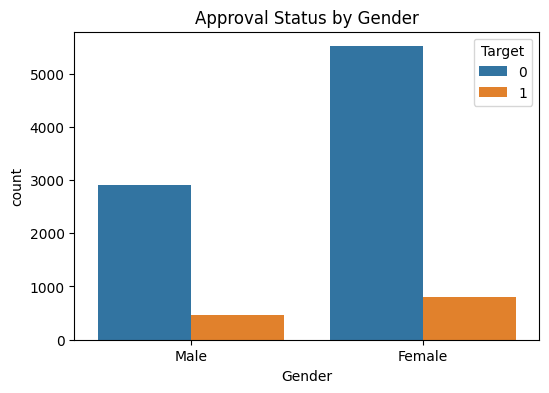

In [27]:
if 'Target' in df.columns and 'Gender' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='Gender', hue='Target')
    plt.title("Approval Status by Gender")
    plt.show()


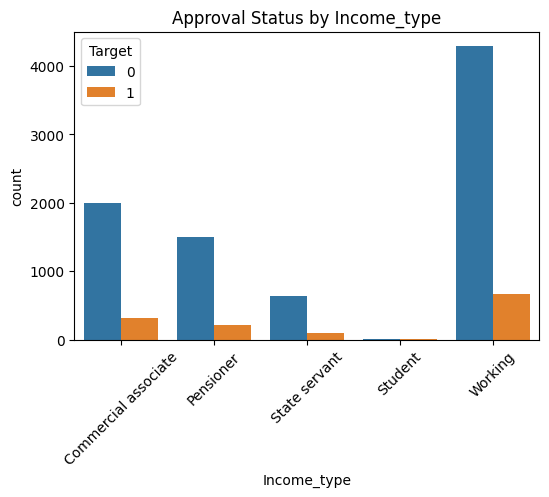

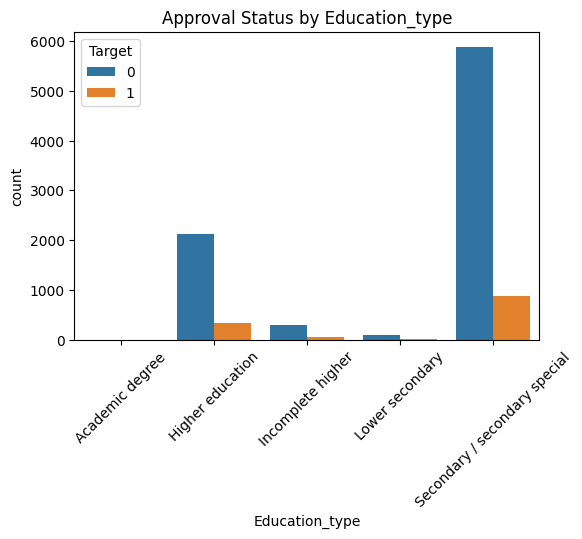

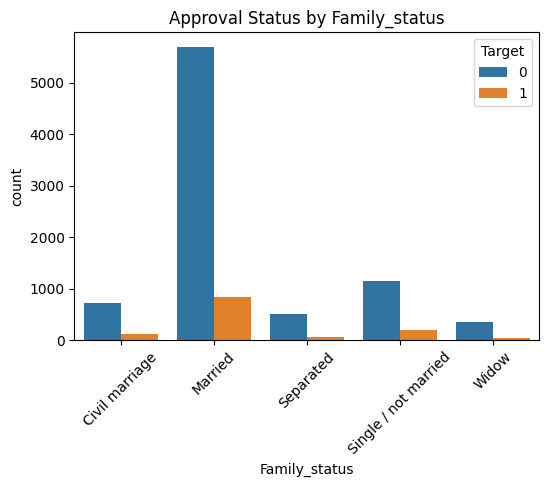

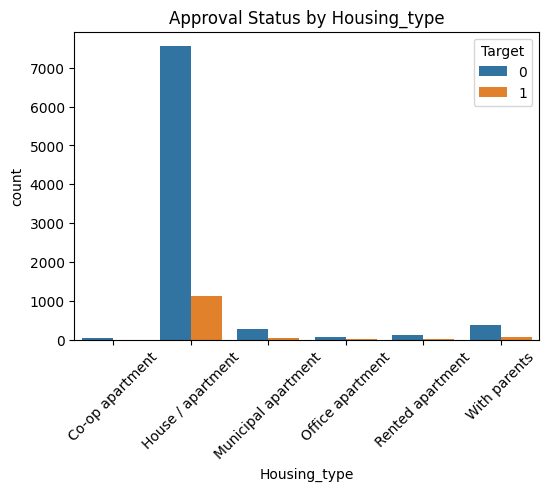

In [28]:
exclude_cols = ['Gender', 'Occupation_type']

# remove excluded columns
filtered_cols = [col for col in cat_cols if col not in exclude_cols]

for col in filtered_cols:
    if col != 'Target':
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col, hue='Target')
        plt.title(f"Approval Status by {col}")
        plt.xticks(rotation=45)
        plt.show()


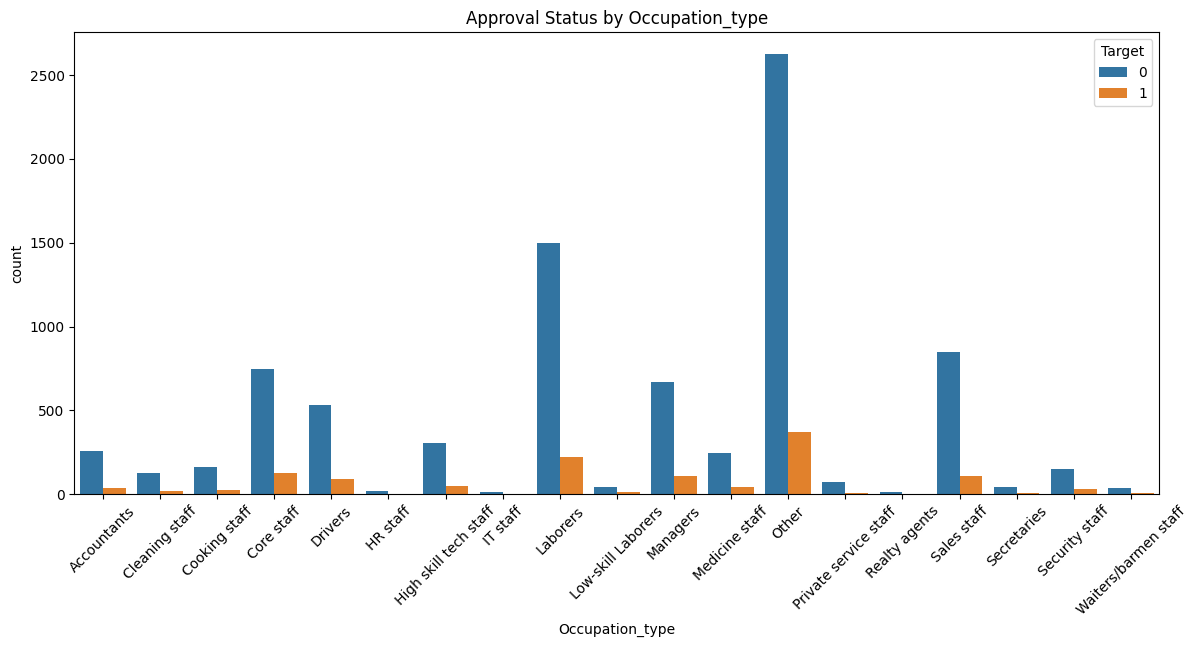

In [29]:
if 'Target' in df.columns and 'Occupation_type' in df.columns:
    plt.figure(figsize=(14,6))
    sns.countplot(data=df, x='Occupation_type', hue='Target')
    plt.title("Approval Status by Occupation_type")
    plt.xticks(rotation=45)
    plt.show()


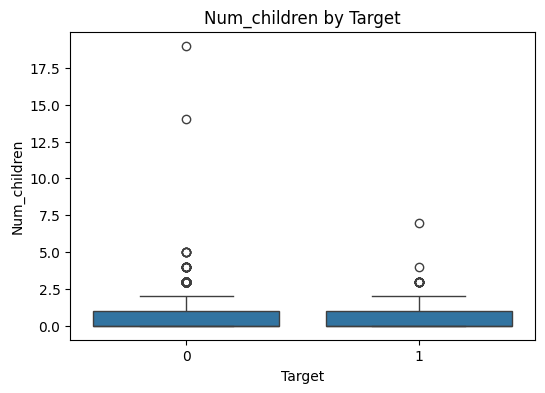

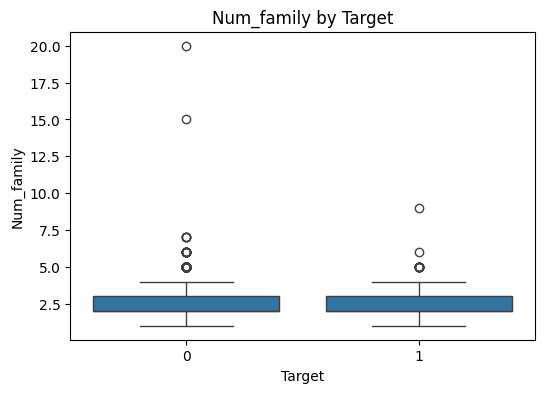

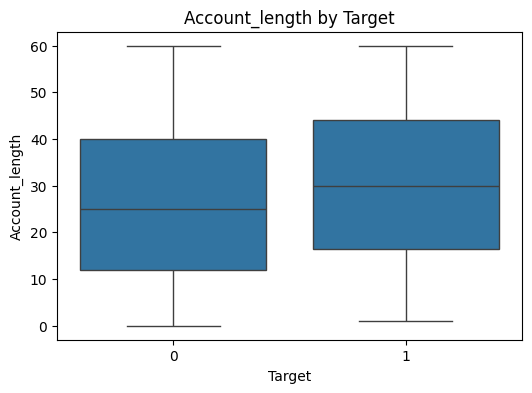

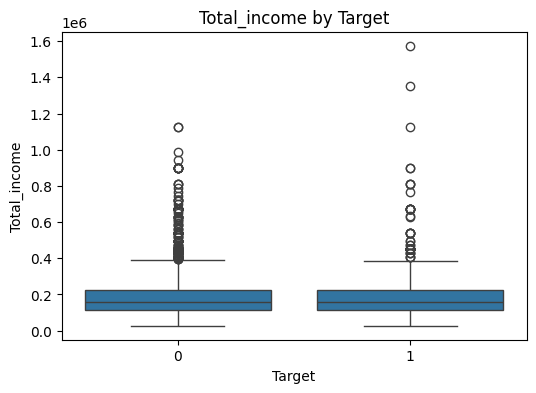

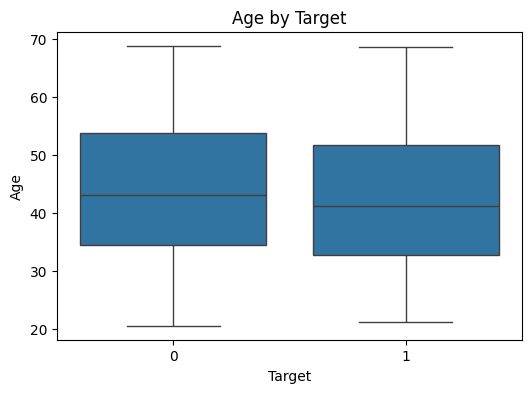

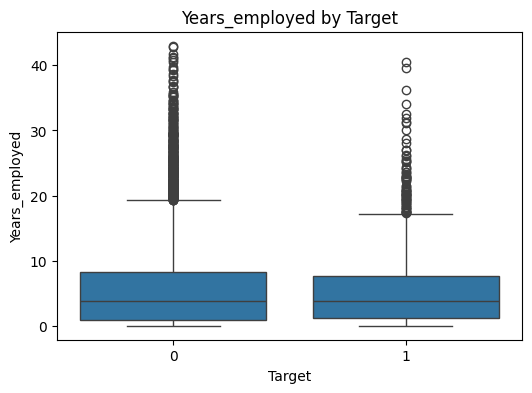

In [30]:
for col in ["Num_children",'Num_family',"Account_length","Total_income","Age","Years_employed"]:
    if 'Target' in df.columns:
        plt.figure(figsize=(6,4))
        sns.boxplot(x='Target', y=col, data=df)
        plt.title(f"{col} by Target")
        plt.show()


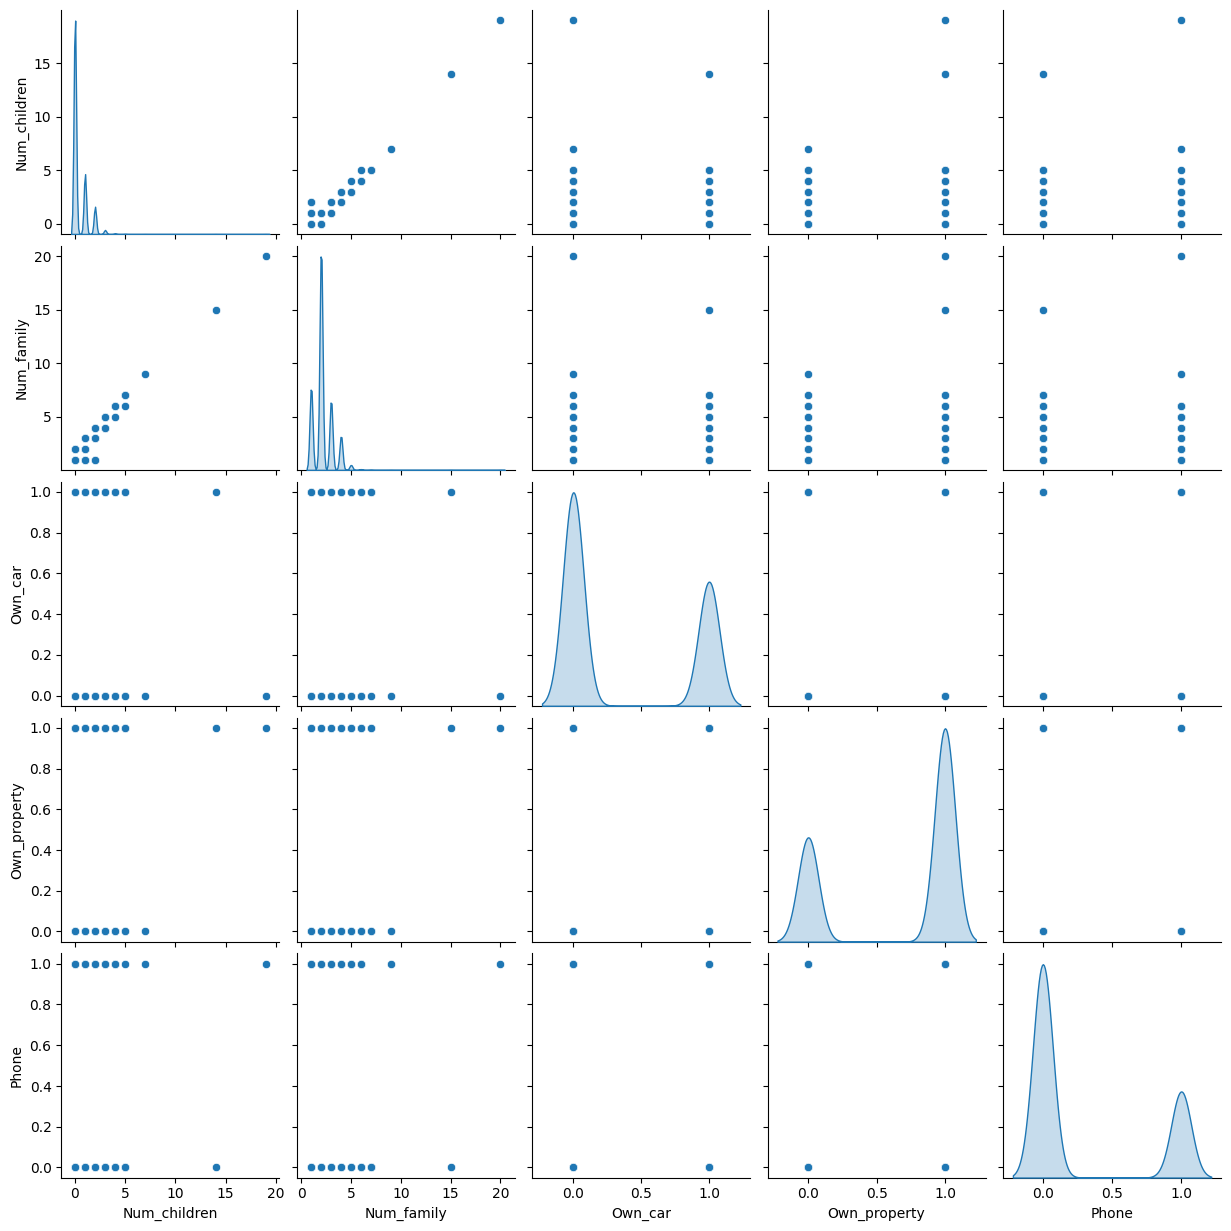

In [31]:
sns.pairplot(df[num_cols2], diag_kind='kde')
plt.show()


In [32]:
corr = df[num_cols].corr()
corr


,ID,Own_car,Own_property,Work_phone,Phone,Email,Unemployed,Num_children,Num_family,Account_length,Total_income,Age,Years_employed,Target
ID,1.000000,-0.003829,-0.071906,0.067723,0.005400,-0.025062,-0.029437,0.021149,0.015102,-0.005465,-0.003212,-0.040211,-0.019097,0.000384
Own_car,-0.003829,1.000000,-0.010190,0.029406,0.004253,0.022261,-0.145493,0.089565,0.138548,0.025058,0.221874,-0.127670,0.019096,-0.006787
Own_property,-0.071906,-0.010190,1.000000,-0.184285,-0.052136,0.056014,0.086675,-0.000480,0.008782,-0.009627,0.025562,0.134602,-0.021443,-0.028227
Work_phone,0.067723,0.029406,-0.184285,1.000000,0.288331,-0.040473,-0.242499,0.052890,0.062499,0.015013,-0.030854,-0.180719,0.107966,-0.002919
Phone,0.005400,0.004253,-0.052136,0.288331,1.000000,0.007631,0.000066,-0.023997,-0.013669,0.021386,0.021051,0.044856,0.041816,-0.009461
Email,-0.025062,0.022261,0.056014,-0.040473,0.007631,1.000000,-0.081081,0.010271,0.004601,-0.024376,0.092321,-0.110262,-0.004703,0.007184
Unemployed,-0.029437,-0.145493,0.086675,-0.242499,0.000066,-0.081081,1.000000,-0.224611,-0.212479,0.005605,-0.166422,0.617513,-0.410936,-0.024926
Num_children,0.021149,0.089565,-0.000480,0.052890,-0.023997,0.010271,-0.224611,1.000000,0.889970,-0.009064,0.031950,-0.322574,0.039159,0.011715
Num_family,0.015102,0.138548,0.008782,0.062499,-0.013669,0.004601,-0.212479,0.889970,1.000000,0.012132,0.028992,-0.275471,0.055838,0.007077
Account_length,-0.005465,0.025058,-0.009627,0.015013,0.021386,-0.024376,0.005605,-0.009064,0.012132,1.000000,0.023211,0.088337,0.083700,0.077492


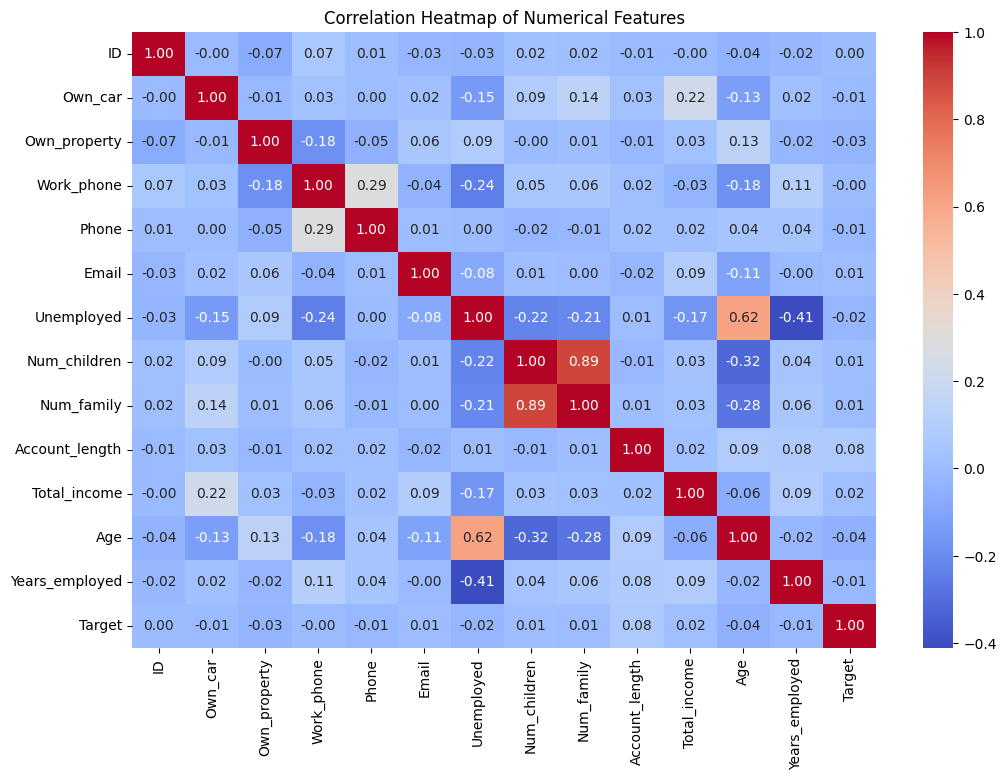

In [33]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


In [34]:
num_cols

Index(['ID', 'Own_car', 'Own_property', 'Work_phone', 'Phone', 'Email',
       'Unemployed', 'Num_children', 'Num_family', 'Account_length',
       'Total_income', 'Age', 'Years_employed', 'Target'],
      dtype='object')

In [35]:
corr = df[num_cols].corr()
corr['Target'].sort_values(ascending=False)


Target            1.000000
Account_length    0.077492
Total_income      0.018784
Num_children      0.011715
Email             0.007184
Num_family        0.007077
ID                0.000384
Work_phone       -0.002919
Own_car          -0.006787
Years_employed   -0.009346
Phone            -0.009461
Unemployed       -0.024926
Own_property     -0.028227
Age              -0.043654
Name: Target, dtype: float64

In [36]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    if col != 'Target':
        print(f"\n{col} vs risk_status:")
        print(df.groupby(col)['Target'].value_counts(normalize=True))



Gender vs risk_status:
Gender  Target
Female  0         0.871580
        1         0.128420
Male    0         0.860898
        1         0.139102
Name: proportion, dtype: float64

Income_type vs risk_status:
Income_type           Target
Commercial associate  0         0.864187
                      1         0.135813
Pensioner             0         0.877921
                      1         0.122079
State servant         0         0.875346
                      1         0.124654
Student               0         0.666667
                      1         0.333333
Working               0         0.865121
                      1         0.134879
Name: proportion, dtype: float64

Education_type vs risk_status:
Education_type                 Target
Academic degree                0         0.666667
                               1         0.333333
Higher education               0         0.864469
                               1         0.135531
Incomplete higher              0         0.830189

C:\Users\abdul\AppData\Local\Temp\ipykernel_22544\1913353330.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(col)['Target'].value_counts(normalize=True))
C:\Users\abdul\AppData\Local\Temp\ipykernel_22544\1913353330.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(col)['Target'].value_counts(normalize=True))
C:\Users\abdul\AppData\Local\Temp\ipykernel_22544\1913353330.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futu

In [37]:
from sklearn.feature_selection import mutual_info_classif

X = df[num_cols]
y = df['Target'].astype('category').cat.codes

mi = mutual_info_classif(X, y)
pd.Series(mi, index=num_cols).sort_values(ascending=False)


Target            0.390548
Unemployed        0.013279
Total_income      0.007782
Age               0.006350
Own_property      0.005347
Email             0.003494
Years_employed    0.001913
Account_length    0.001475
ID                0.001098
Own_car           0.000000
Phone             0.000000
Work_phone        0.000000
Num_family        0.000000
Num_children      0.000000
dtype: float64